In [1]:
import os
import sys
import yaml
import glob
import torch
sys.path.append("/mnt/home/ubuntu/workspace/code/compositional-representation-learning")

In [20]:
# Load config
config_path = "/mnt/home/ubuntu/workspace/code/compositional-representation-learning/configs/SubspaceConceptLattice/scl_exp_34.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Get checkpoint mapping
ckpt_dir = "/mnt/home/ubuntu/workspace/experiment_root_dir/SubspaceConceptLattice/scl_exp_34/scl_exp_34___2026-03-11__15-04-17/checkpoints/"
ckpt_paths = sorted(glob.glob(os.path.join(ckpt_dir, "*.ckpt")))
ckpt_mapping = {i: path for i, path in enumerate(ckpt_paths)}

print(f"Found {len(ckpt_mapping)} checkpoints.")

# Initialize model and load the first checkpoint
if ckpt_mapping:
    first_ckpt = ckpt_mapping[0]
    # Initialize from checkpoint
    model = SubspaceConceptLattice.load_from_checkpoint(first_ckpt, config=config)
    model.eval()
    print(f"Loaded checkpoint: {first_ckpt}")
else:
    print("No checkpoints found.")


Found 100 checkpoints.
Loaded checkpoint: /mnt/home/ubuntu/workspace/experiment_root_dir/SubspaceConceptLattice/scl_exp_34/scl_exp_34___2026-03-11__15-04-17/checkpoints/model-epoch=000.ckpt


/home/ubuntu/miniconda3/envs/vh-crl/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [21]:
ckpt = ckpt_mapping[99]
model = SubspaceConceptLattice.load_from_checkpoint(ckpt, config=config)
model.eval()

SubspaceConceptLattice(
  (perceptual_encoder): ViTEncoder(
    (patch_embed): Conv2d(3, 128, kernel_size=(8, 8), stride=(8, 8))
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (concept_encoder): ConceptEncoder(
    (attn): MultiheadAt

In [22]:
import itertools
import numpy as np
import cv2
import torch
from torchvision import transforms

# Get config
train_config = config["data"]["train"]["config"]
img_size = train_config.get("image_size", 64)
if isinstance(img_size, (list, tuple)):
    img_size_x, img_size_y = img_size
else:
    img_size_x = img_size_y = img_size

shapes = train_config.get("shapes", ["circle", "square"])
colors = train_config.get("colors", ["red", "blue", "green"])

color_map = {"red": (255, 0, 0), "green": (0, 255, 0), "blue": (0, 0, 255),
             "yellow": (255, 255, 0), "cyan": (0, 255, 255), "magenta": (255, 0, 255),
             "white": (255, 255, 255), "black": (0, 0, 0)}

default_transform = transforms.Compose([
    transforms.ToTensor(),
])

center_val = train_config.get("center_range", [32, 33])[0]
size_val = train_config.get("size_range", [20, 21])[0]

def make_ideal_img(shape, color_name, device):
    img = np.zeros([img_size_x, img_size_y, 3], dtype=np.uint8)
    color = color_map.get(color_name, (255, 255, 255))
    center = (center_val, center_val)
    
    if shape == "circle":
        radius = size_val // 2
        cv2.circle(img, center, radius, color, -1)
    elif shape == "square":
        side = size_val
        cv2.rectangle(img, 
                    (center[0] - side // 2, center[1] - side // 2), 
                    (center[0] + side // 2, center[1] + side // 2), 
                    color, -1)
                    
    img_tensor = default_transform(img)
    return img_tensor.to(device)

combinations = list(itertools.product(colors, shapes))

images = []
singleton_labels = []
for c, s in combinations:
    images.append(make_ideal_img(s, c, model.device))
    singleton_labels.append(f"{c.capitalize()} {s.capitalize()}")

images = torch.stack(images) # (num_singletons, 3, H, W)
num_singletons = len(combinations)

# 2. Get perceptual representations
with torch.no_grad():
    R = model.perceptual_encoder(images) # (num_singletons, num_patches, embed_dim)

# 3. Define the formal concepts dynamically
concept_defs = {}

# Universal concept
concept_defs["C0 (Universal)"] = list(range(num_singletons))

concept_idx = 1
# Color concepts
for color in colors:
    concept_defs[f"C{concept_idx} ({color.capitalize()})"] = [
        i for i, (c, s) in enumerate(combinations) if c == color
    ]
    concept_idx += 1
    
# Shape concepts
for shape in shapes:
    concept_defs[f"C{concept_idx} ({shape.capitalize()})"] = [
        i for i, (c, s) in enumerate(combinations) if s == shape
    ]
    concept_idx += 1
    
# Singleton concepts
for i, (c, s) in enumerate(combinations):
    concept_defs[f"C{concept_idx} ({c.capitalize()} {s.capitalize()})"] = [i]
    concept_idx += 1

# Extract representations for all concepts
concept_mapping = {}

print("Extracting representations for concepts...")
with torch.no_grad():
    for name, indices in concept_defs.items():
        subset = R[indices].unsqueeze(0) # (1, subset_size, num_patches, embed_dim)
        X_attr, X_obj, P_attr, P_obj = model.concept_encoder(subset)
        
        concept_mapping[name] = {
            "X_attr": X_attr.squeeze(0).detach(),
            "X_obj": X_obj.squeeze(0).detach(),
            "P_attr": P_attr.squeeze(0).detach(),
            "P_obj": P_obj.squeeze(0).detach(),
            "indices": indices
        }

print(f"Extracted representations for {len(concept_mapping)} concepts.")


Extracting representations for concepts...
Extracted representations for 9 concepts.


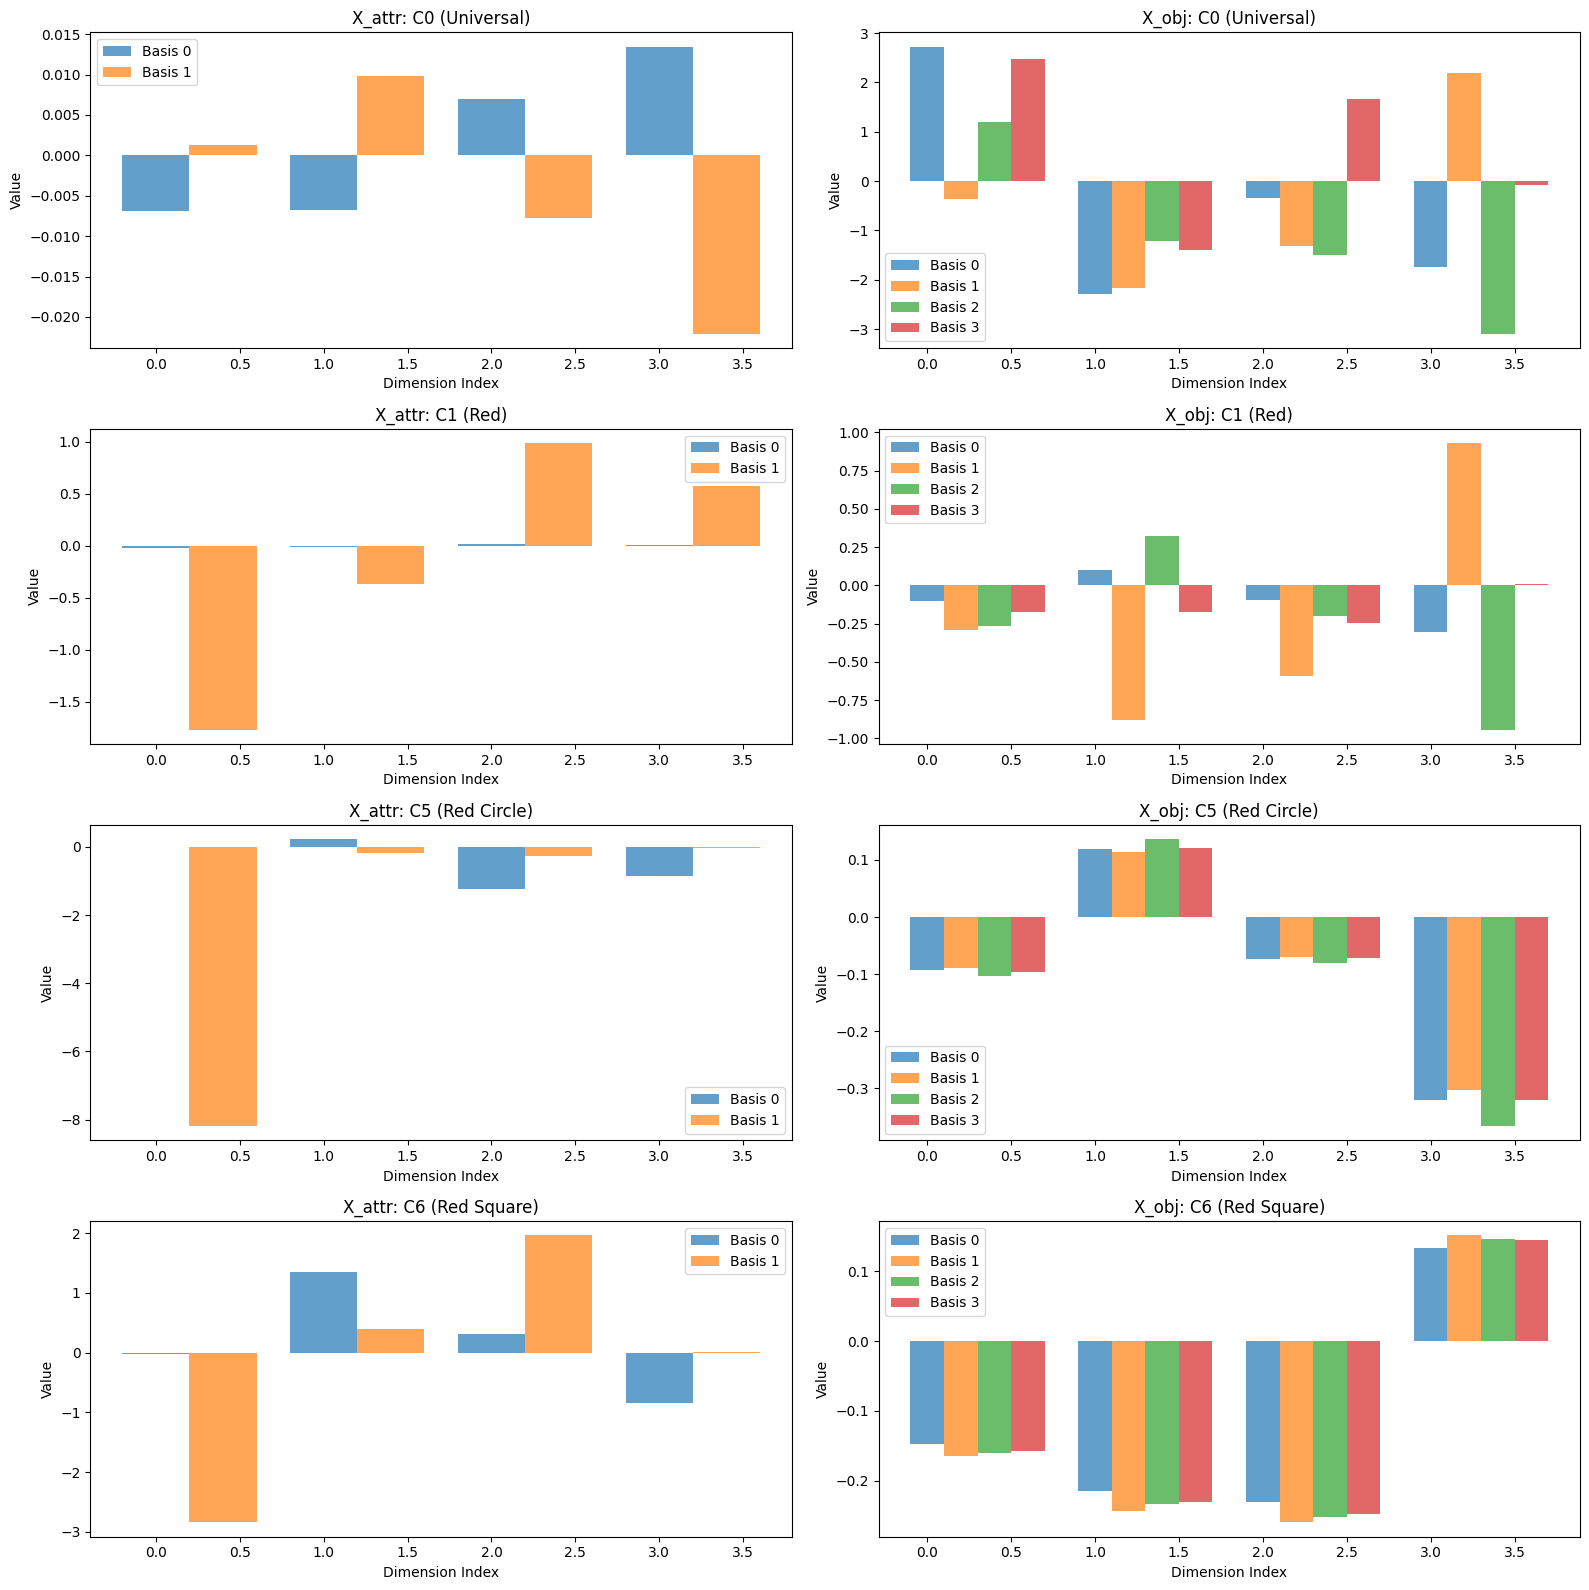

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# We want to focus on "Red Circle", "Red Square", "Red", and "Universal" Concepts
targets = ["(Universal)", "(Red)", "(Red Circle)", "(Red Square)"]
keys_to_plot = []

# Find the exact keys in the concept_mapping generated by the previous cell
for target in targets:
    for k in concept_mapping.keys():
        if target in k:
            keys_to_plot.append(k)
            break

# Create a figure with a row for each target concept and 2 columns (X_attr and X_obj)
fig, axes = plt.subplots(len(keys_to_plot), 2, figsize=(16, 4 * len(keys_to_plot)))

for i, key in enumerate(keys_to_plot):
    # concept_mapping[key]["X_attr"] and ["X_obj"] have shape (n_attr/n_obj, d_ambient)
    x_attr = concept_mapping[key]["X_attr"].cpu().numpy()
    x_obj = concept_mapping[key]["X_obj"].cpu().numpy()
    
    # Ensure 2D for iteration over basis vectors
    if x_attr.ndim == 1:
        x_attr = x_attr[np.newaxis, :]
    if x_obj.ndim == 1:
        x_obj = x_obj[np.newaxis, :]
        
    ax_attr = axes[i, 0]
    ax_obj = axes[i, 1]
    
    n_attr, d_ambient_attr = x_attr.shape
    bar_width_attr = 0.8 / n_attr
    for r in range(n_attr):
        ax_attr.bar(np.arange(d_ambient_attr) + r * bar_width_attr, x_attr[r], 
                    width=bar_width_attr, alpha=0.7, label=f"Basis {r}")
    ax_attr.set_title(f"X_attr: {key}")
    ax_attr.set_xlabel("Dimension Index")
    ax_attr.set_ylabel("Value")
    if n_attr > 1:
        ax_attr.legend()
        
    n_obj, d_ambient_obj = x_obj.shape
    bar_width_obj = 0.8 / n_obj
    for r in range(n_obj):
        ax_obj.bar(np.arange(d_ambient_obj) + r * bar_width_obj, x_obj[r], 
                   width=bar_width_obj, alpha=0.7, label=f"Basis {r}")
    ax_obj.set_title(f"X_obj: {key}")
    ax_obj.set_xlabel("Dimension Index")
    ax_obj.set_ylabel("Value")
    if n_obj > 1:
        ax_obj.legend()

plt.tight_layout()
plt.show()


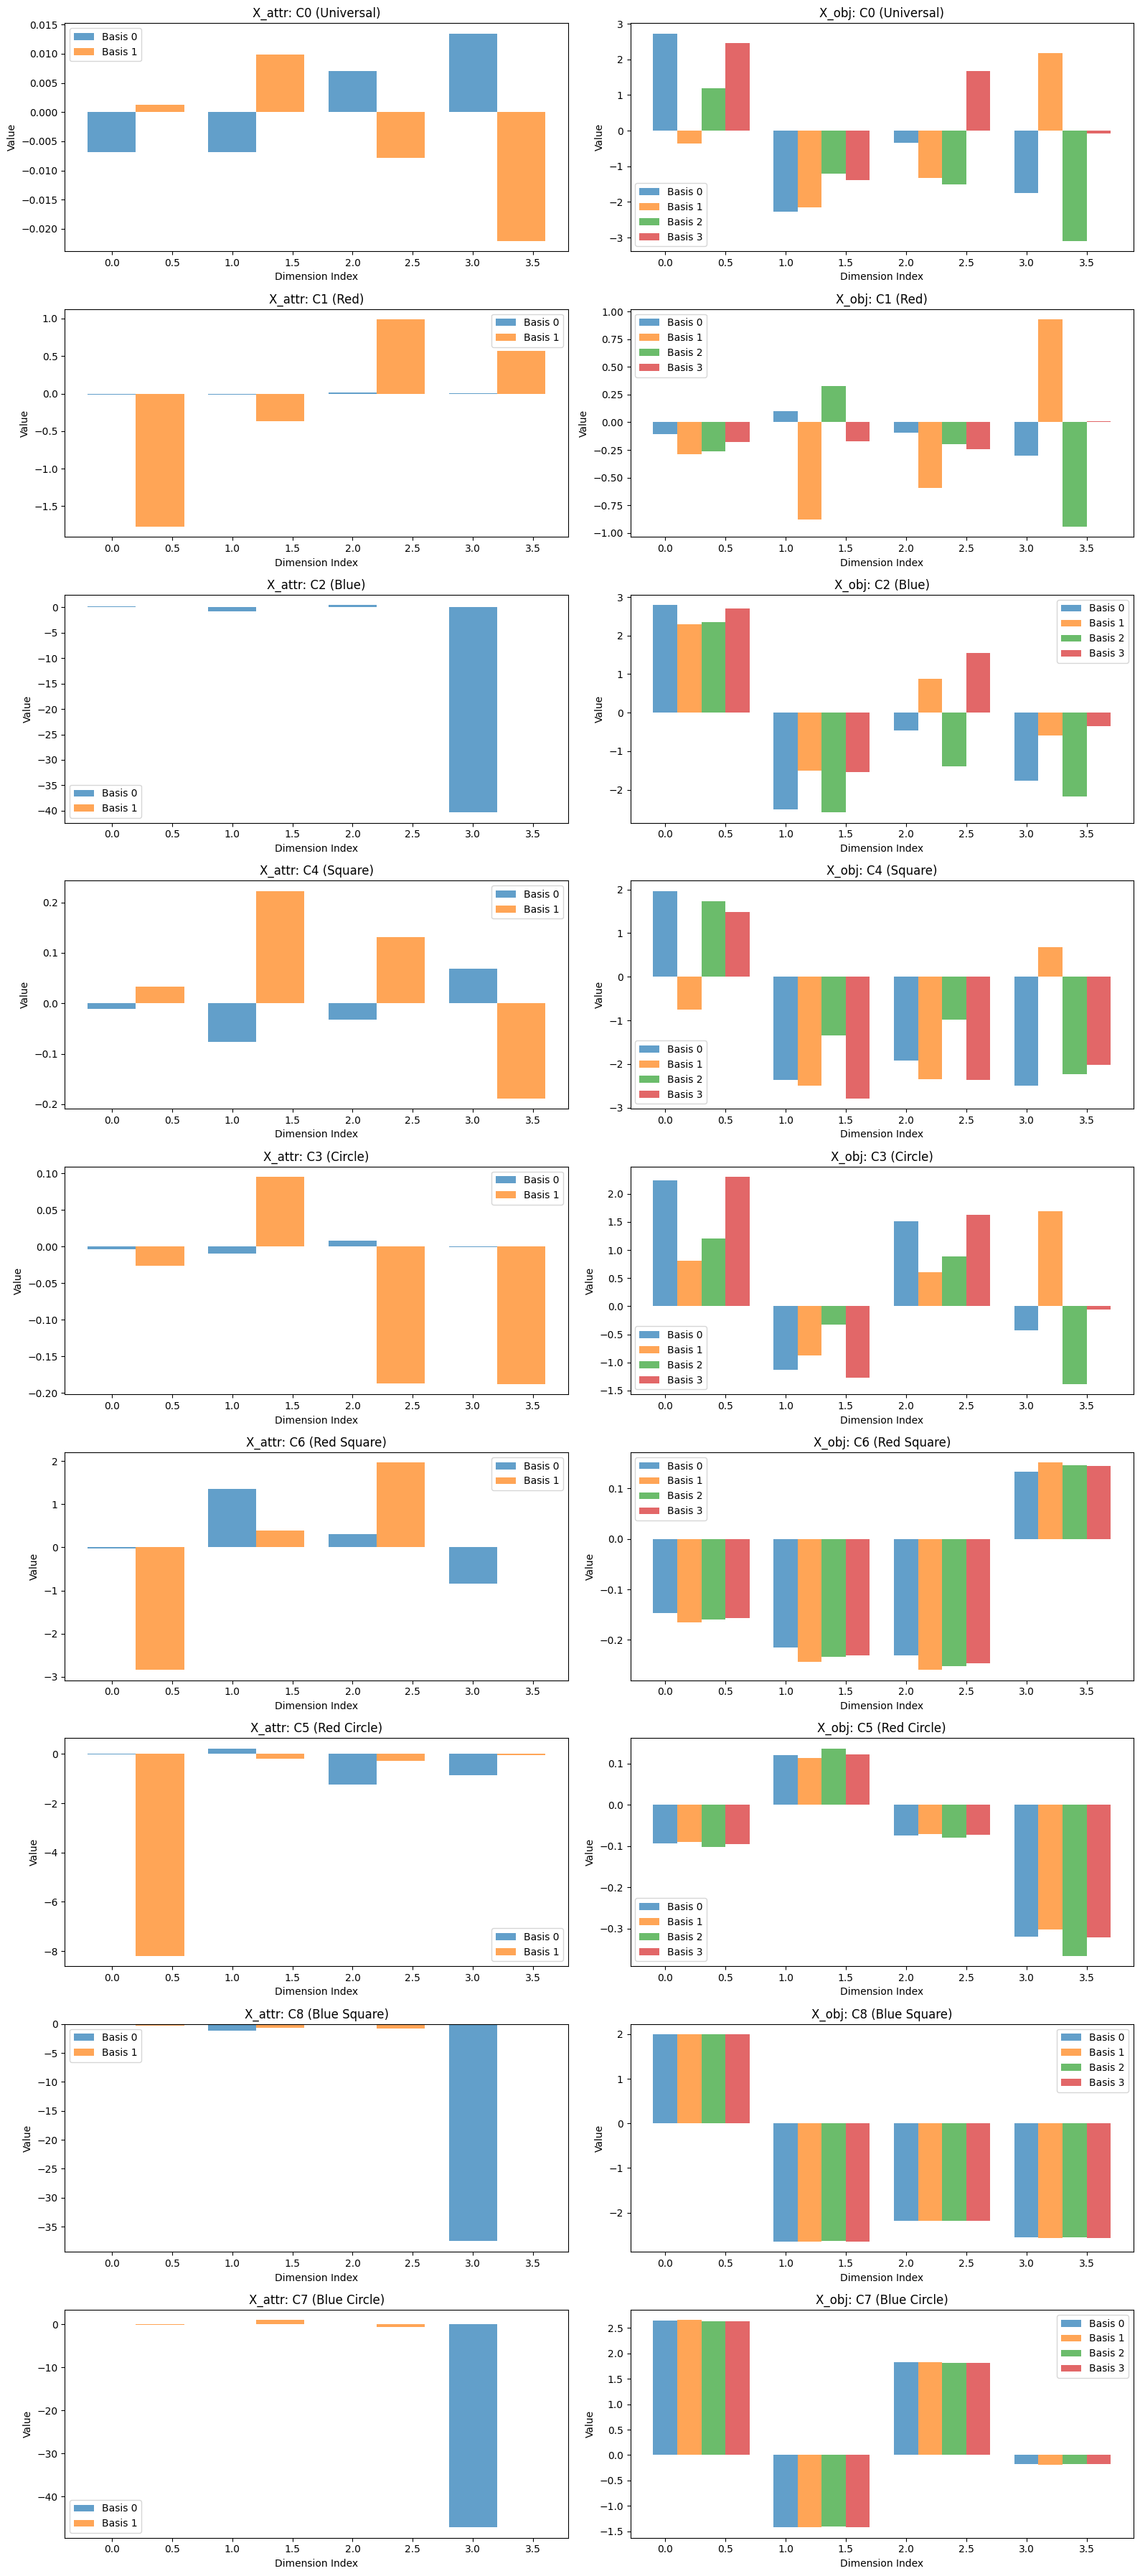

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# We want to focus on "Red Circle", "Red Square", "Red", and "Universal" Concepts
targets = ["(Universal)", "(Red)", "(Blue)", "(Square)", "(Circle)", "(Red Square)", "(Red Circle)", "(Blue Square)", "(Blue Circle)"]
keys_to_plot = []

# Find the exact keys in the concept_mapping generated by the previous cell
for target in targets:
    for k in concept_mapping.keys():
        if target in k:
            keys_to_plot.append(k)
            break

# Create a figure with a row for each target concept and 2 columns (X_attr and X_obj)
fig, axes = plt.subplots(len(keys_to_plot), 2, figsize=(16, 4 * len(keys_to_plot)))

for i, key in enumerate(keys_to_plot):
    # concept_mapping[key]["X_attr"] and ["X_obj"] have shape (n_attr/n_obj, d_ambient)
    x_attr = concept_mapping[key]["X_attr"].cpu().numpy()
    x_obj = concept_mapping[key]["X_obj"].cpu().numpy()
    
    # Ensure 2D for iteration over basis vectors
    if x_attr.ndim == 1:
        x_attr = x_attr[np.newaxis, :]
    if x_obj.ndim == 1:
        x_obj = x_obj[np.newaxis, :]
        
    ax_attr = axes[i, 0]
    ax_obj = axes[i, 1]
    
    n_attr, d_ambient_attr = x_attr.shape
    bar_width_attr = 0.8 / n_attr
    for r in range(n_attr):
        ax_attr.bar(np.arange(d_ambient_attr) + r * bar_width_attr, x_attr[r], 
                    width=bar_width_attr, alpha=0.7, label=f"Basis {r}")
    ax_attr.set_title(f"X_attr: {key}")
    ax_attr.set_xlabel("Dimension Index")
    ax_attr.set_ylabel("Value")
    if n_attr > 1:
        ax_attr.legend()
        
    n_obj, d_ambient_obj = x_obj.shape
    bar_width_obj = 0.8 / n_obj
    for r in range(n_obj):
        ax_obj.bar(np.arange(d_ambient_obj) + r * bar_width_obj, x_obj[r], 
                   width=bar_width_obj, alpha=0.7, label=f"Basis {r}")
    ax_obj.set_title(f"X_obj: {key}")
    ax_obj.set_xlabel("Dimension Index")
    ax_obj.set_ylabel("Value")
    if n_obj > 1:
        ax_obj.legend()

plt.tight_layout()
plt.show()
